<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
NETID = "cfinley6"

df = pd.read_csv(f"{NETID}_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,mpld3_mpld3,001480cc13dff0720cd88838a462dd3b8b10034e,Jake Vanderplas <vanderplas@astro.washington.edu>,1388542748,update create_example\n,2014-01
1,mpld3_mpld3,004fec51a759ab09f7be77f8d6ab37f005ec55f9,Vlad-Ștefan Harbuz <vlad@vladh.net>,1591607440,Remove issue template\n,2020-06
2,mpld3_mpld3,006cbf7a20d9883199e5bba080a51060d5f905fe,Ahmed Hassan <Ahmed@Linuxism.com>,1395544280,Made the documentation more clear\n,2014-03
3,mpld3_mpld3,0071dcbb518b049c4ecc740d29f5ad8e798e1663,Jake Vanderplas <jakevdp@gmail.com>,1387554249,Merge pull request #2 from wrobstory/PR_deps\n...,2013-12
4,mpld3_mpld3,007d0b5ac6d8db84b109d7b9215e56fe70815c29,Jake Vanderplas <vanderplas@astro.washington.edu>,1395766438,DOC: add missing features to FAQ\n,2014-03


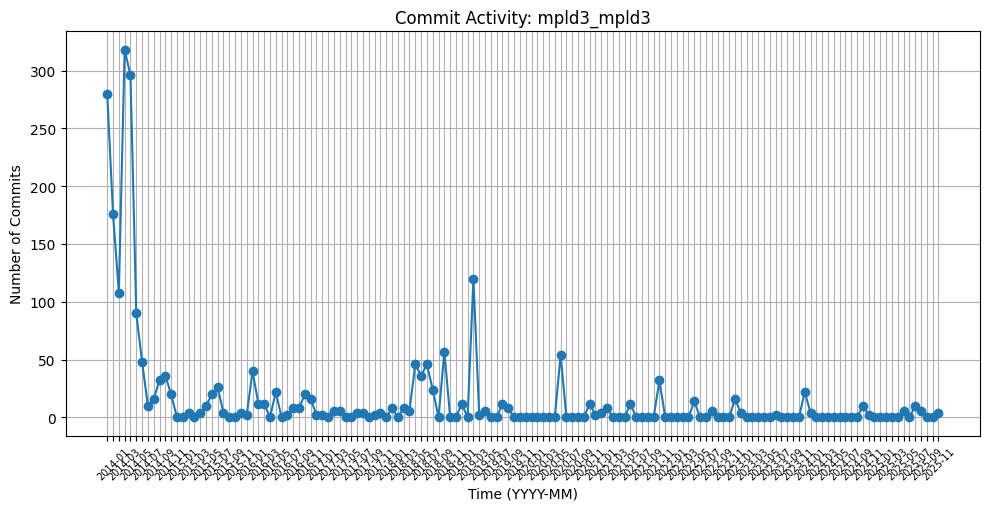

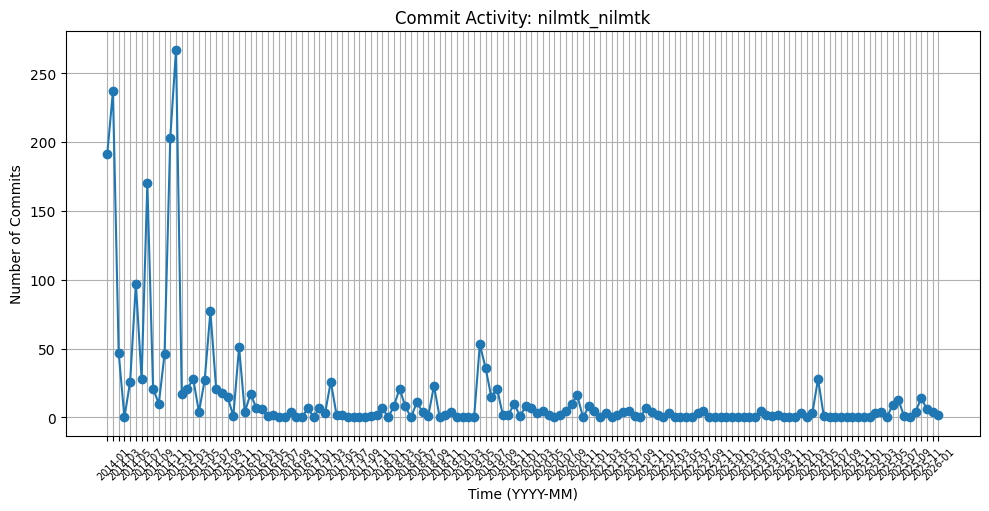

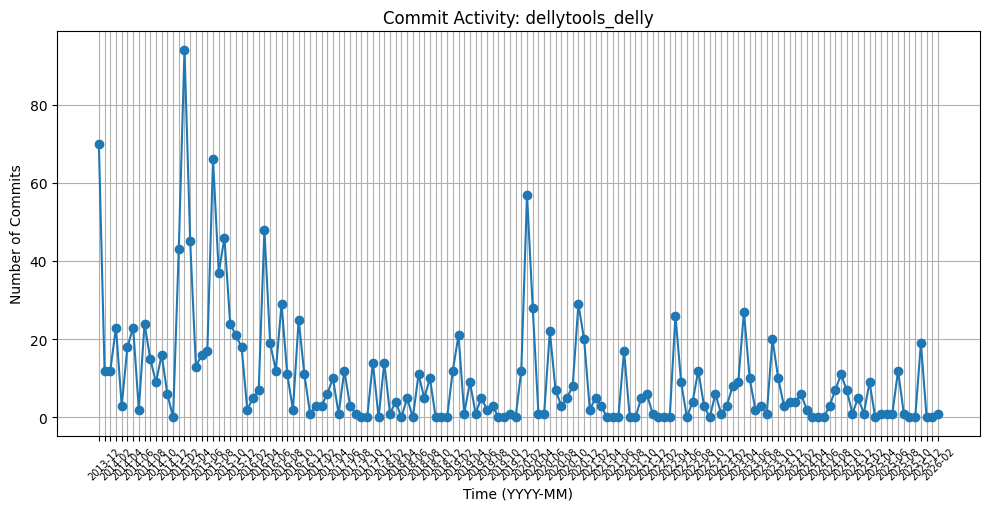

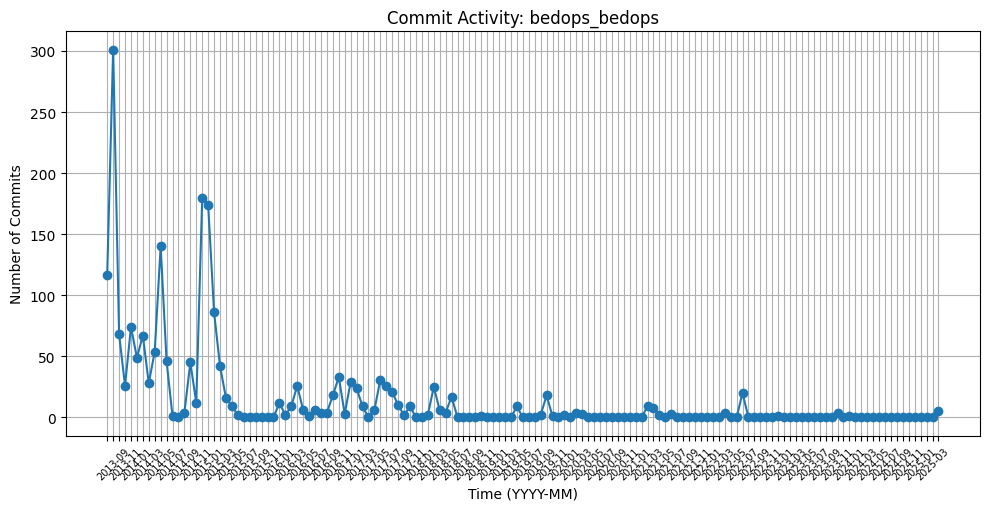

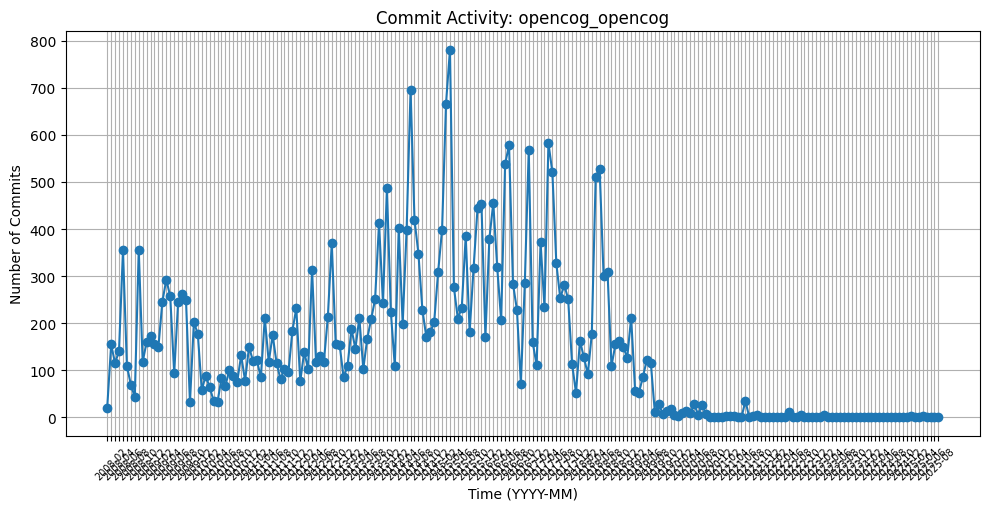

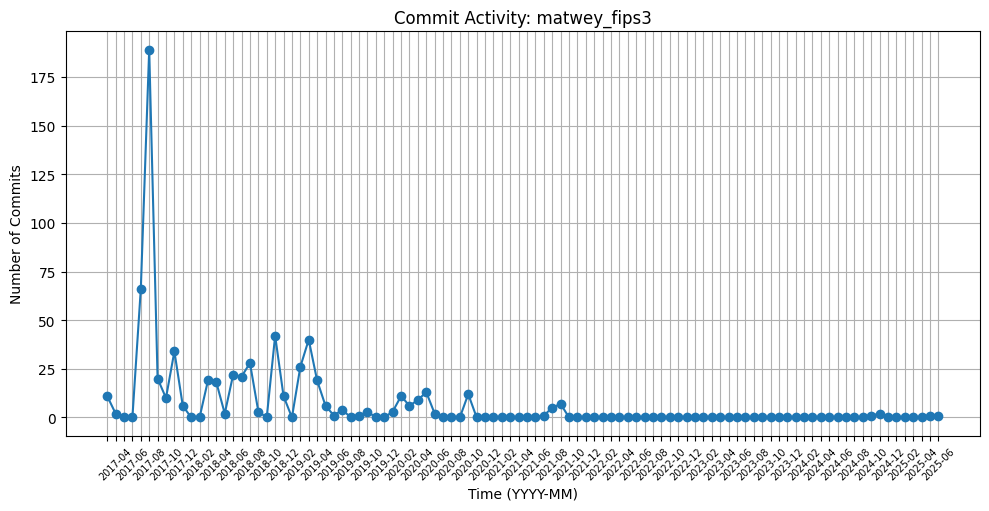

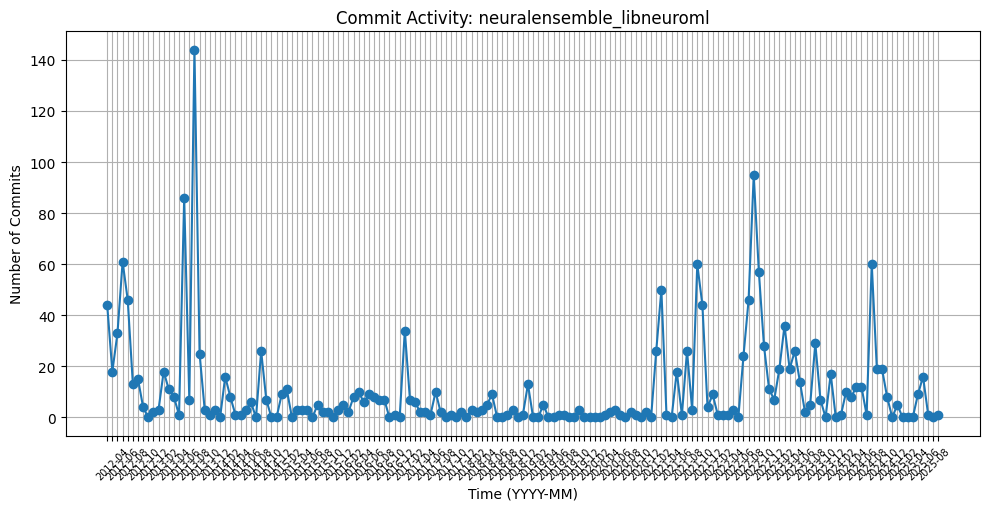

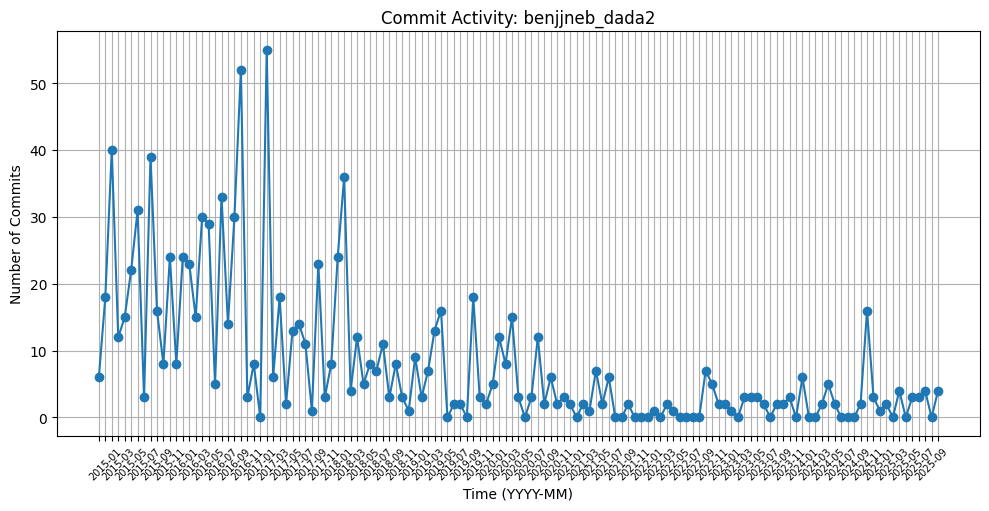

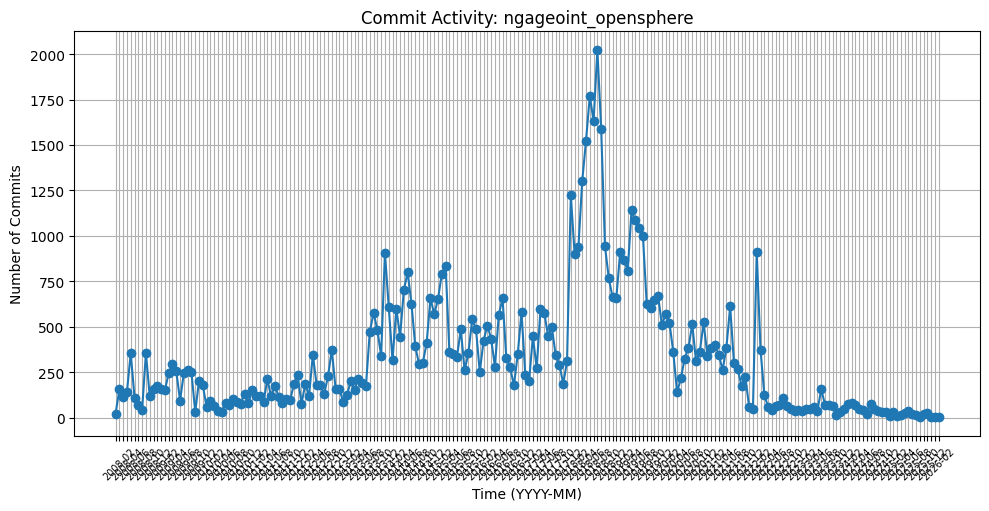

In [8]:
import matplotlib.ticker as ticker

project_col = 'project'
my_projects = df[project_col].unique()

for prj in my_projects:
    # 1. Filter for the current project
	df1 = df[df[project_col] == prj].copy()
    
	df2 = df1.groupby('Month').size().reset_index(name='Commits')
	monthly_counts = df2
	monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])

	full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
	
	monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
	monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
	monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)

	plt.figure(figsize=(10,5))
	plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
	plt.xlabel("Time (YYYY-MM)")
	plt.ylabel("Number of Commits")
	plt.title("Commit Activity: "+prj)
	plt.grid(True)
	plt.tight_layout()
	ax =  plt.gca()
	for label in ax.xaxis.get_ticklabels()[::2]:
		label.set_visible(False)
	plt.xticks(rotation=45, fontsize=7)
	plt.savefig(f"{NETID}_timeseries_"+prj+".png", dpi=600)
	plt.show()
	plt.close()


# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv